In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## Functions


In [2]:
def dt_to_hours(a):
    return a.hour+a.minute/60+a.second/3600

def to_hours(s):
    s = s.split(' ')[-1]
    hours, minutes, seconds = [float(x) for x in s.split(':')]
    return hours + minutes/60 + seconds/3600

## Get data

In [3]:
fn = 'plan_and_results.xlsx'
well_to_cs_fn = 'plate_mapping.csv'

In [4]:
well_to_cs = pd.read_csv(well_to_cs_fn).set_index('Well').to_dict(orient='dict')['Carbon source']

In [5]:
fn_At = 'At/250523_growth_phenotyping_At.txt'
fn_Ct = 'Ct/230526_growth_phenotyping_ct.txt'
fn_Oa = 'Oa/230526_growth_phenotyping_2_oa.txt'
fn_Ms = 'Ms/300523_growth_phenotyping_Ms.txt'

In [6]:
inoculation_od = 0.05 # Check this


In [156]:
# At_od = pd.read_excel(fn_At, sheet_name='Plate 1 - Sheet1', header=0, nrows=151, skiprows=51, converters={'Time':pd.datetime}).iloc[:, 1:]
At_od = pd.read_csv(fn_At, skiprows=65, nrows = 98, header = None, sep='\t', encoding='latin-1', index_col = 0).iloc[:,:-1].T
Ct_od = pd.read_csv(fn_Ct, skiprows=66, nrows = 151, header = 0, sep='\t', encoding='latin-1')
Oa_od = pd.read_csv(fn_Oa, skiprows=66, nrows = 151, header = 0, sep='\t', encoding='latin-1')
Ms_od = pd.read_csv(fn_Ms, skiprows=65, nrows = 98, header = None, sep='\t', encoding='latin-1', index_col = 0).iloc[:,:-6].T


At_od['Hours'] = At_od.Time.map(to_hours)
Ct_od['Hours'] = Ct_od.Time.map(to_hours)
Oa_od['Hours'] = Oa_od.Time.map(to_hours)
Ms_od['Hours'] = Ms_od.Time.map(to_hours)

At_od.drop(columns = ['Time', 'T° Read 2:600'], inplace = True)
Ct_od.drop(columns = Ct_od.columns[:2], inplace = True)
Oa_od.drop(columns = Oa_od.columns[:2], inplace = True)
Ms_od.drop(columns = ['Time', 'T° Read 2:600'], inplace = True)


At_od['Species'] = 'At'
Ct_od['Species'] = 'Ct'
Oa_od['Species'] = 'Oa'
Ms_od['Species'] = 'Ml'


At_od['Experiment'] = 'At growth phenotyping'
Ct_od['Experiment'] = 'Ct growth phenotyping'
Oa_od['Experiment'] = 'Oa growth phenotyping'
Ms_od['Experiment'] = 'Ml growth phenotyping'


In [157]:
# Remove outliers
Oa_od.drop(columns=['D5'], inplace=True)
# Oa_od.drop(columns=['F1'], inplace=True)
Ms_od.drop(columns=['A1'], inplace=True)
Ms_od.drop(columns=['B1'], inplace=True)
Ms_od.drop(columns=['C1'], inplace=True)
Ms_od.drop(columns=['D1'], inplace=True)
Ms_od.drop(columns=['E1'], inplace=True)
Ms_od.drop(columns=['F1'], inplace=True)

In [158]:
# Ms_od.loc[::10, ['D1', 'D2', 'D3']]

In [159]:
all_wells = list(well_to_cs.keys())
At = pd.melt(At_od, value_vars=[x for x in all_wells if x in At_od.columns], id_vars = ['Species', 'Hours', 'Experiment'], value_name='OD600', var_name = 'Well')
Ct = pd.melt(Ct_od, value_vars=[x for x in all_wells if x in Ct_od.columns], id_vars = ['Species', 'Hours', 'Experiment'], value_name='OD600', var_name = 'Well')
Oa = pd.melt(Oa_od, value_vars=[x for x in all_wells if x in Oa_od.columns], id_vars = ['Species', 'Hours', 'Experiment'], value_name='OD600', var_name = 'Well')
Ms = pd.melt(Ms_od, value_vars=[x for x in all_wells if x in Ms_od.columns], id_vars = ['Species', 'Hours', 'Experiment'], value_name='OD600', var_name = 'Well')

In [160]:
od_df = pd.concat([At, Ct, Oa, Ms], ignore_index = True)
od_df.OD600 = od_df.OD600.astype(float)
od_df.Hours = od_df.Hours.astype(float)
# od_df.Well = od_df.Well.astype(str)
od_df['Carbon source'] = od_df.Well.map(well_to_cs)

## Add data from additional experiment
Performed by Alisson Gillon in May 2024 to add citrate and pyruvate to the list of compounds

Only a subset is used - the whole datasets include different carbon concentrations and comes from two different experiments. Note that Ct data comes from 5 mM (so 30 mM carbon), in contrast to the other data sets. The reason is that I didn't see growth in the 15 mM cultivation, most likely because of lag time.

I removed well  E12 which seems like an outlier

In [161]:
fn_add = '../allison_growth_phenoptyping_0524/At_Ct_Oa_Ml/od_long_table.csv'
df_add = pd.read_csv(fn_add, index_col=0)


add_idx =  (((df_add['Carbon source'] == 'Citrate') & (df_add['Concentration [mM]']==15) & df_add['Species'].isin(['At', 'Ml', 'Oa']))
          | ((df_add['Carbon source'] == 'Citrate') & (df_add['Concentration [mM]']==5) & df_add['Species'].isin(['Ct']) & df_add['Well'].isin(['B9','B10', 'B11']))
          | ((df_add['Carbon source'] == 'Pyruvate') & (df_add['Concentration [mM]']==30) & (df_add['Experiment']=='070524_growth_phenotyping_4species')))
df_add = df_add.loc[add_idx]

# Remove outlier for Ml on pyruvate well E12
df_add = df_add.loc[df_add.Well!='E12']
# df_add.loc[add_idx, 'Concentration [mM]'].unique()

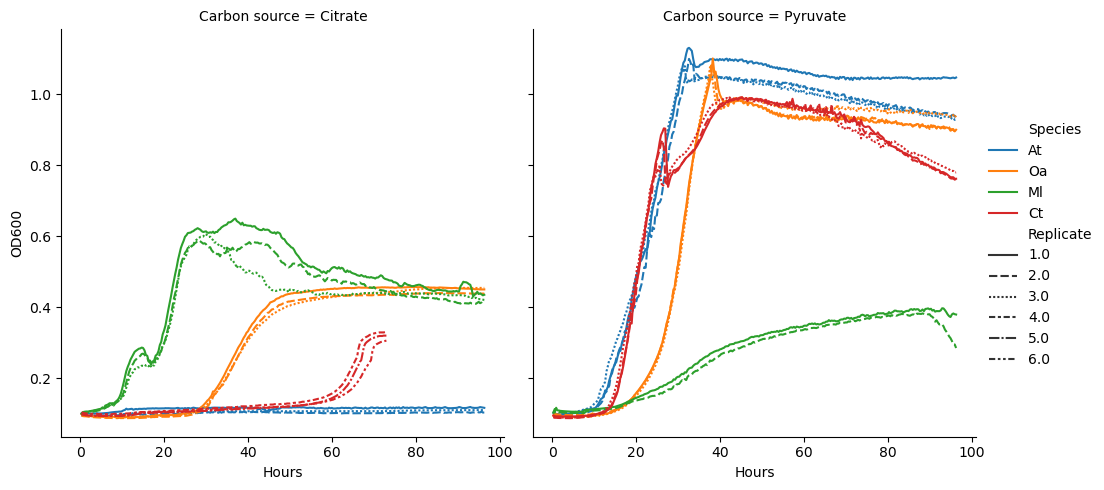

In [162]:
sns.relplot(data = df_add, x = 'Hours', y='OD600', hue = 'Species', col = 'Carbon source', kind = 'line', estimator = None, units = 'Well', style = 'Replicate')
# plt.xlim(0,10)

In [163]:
df = pd.concat([od_df, df_add])
df.rename(columns={'OD600':'Raw OD'}, inplace=True)
df['Carbon source'] = df['Carbon source'].str.capitalize()

In [164]:
df.loc[(df['Experiment']=='070524_growth_phenotyping_4species')&(df.Well == 'A1')].iloc[::100]

,Species,Hours,Experiment,Well,Raw OD,Carbon source,Supplement,Concentration [mM],Replicate
0,At,0.276389,070524_growth_phenotyping_4species,A1,0.1009,Citrate,NaN,15.0,1.0
100,At,33.609722,070524_growth_phenotyping_4species,A1,0.1159,Citrate,NaN,15.0,1.0
200,At,66.943056,070524_growth_phenotyping_4species,A1,0.1166,Citrate,NaN,15.0,1.0


# Correct OD values

In [165]:
# species = od_df.Species.unique()

# od_df['OD'] = np.nan
# for s in species:
#     for cs in cs_list:
#         idx = (od_df.Species == s) & (od_df['Carbon source']==cs)
#         # Mean of first two timepoints
#         mean_od0 = od_df.loc[idx, :].sort_values(by='Hours')[:6]['OD600'].mean()
#         od_df.loc[idx, 'OD'] = od_df.loc[idx, 'OD600']-mean_od0+inoculation_od
# # df['Time'] = df['Hours']

## Decided to just set the mean of all inital OD values to the inoculum

In [166]:
wells = df.Well.unique()
experiments = df.Experiment.unique()
df['OD'] = np.nan
for e in experiments:
    for w in wells:
        idx = (df.Experiment==e) & (df.Well == w)
        if idx.sum()>0:
            mean_inital_od_diff = (df.loc[idx, 'Raw OD'][:6].mean()-inoculation_od)
            df.loc[idx, 'OD'] = df.loc[idx, 'Raw OD'] - mean_inital_od_diff

In [167]:
df.to_csv('od_all_species_long.csv')

In [168]:
n_rows = 6
n_cols = 6

In [169]:
palette = sns.palettes.color_palette('tab10')
palette = [palette[i] for i in [2,1,0,3]]

In [170]:
cs_list = sorted(df['Carbon source'].unique(), key=lambda x: (x == "No cs", x))
max_time =72

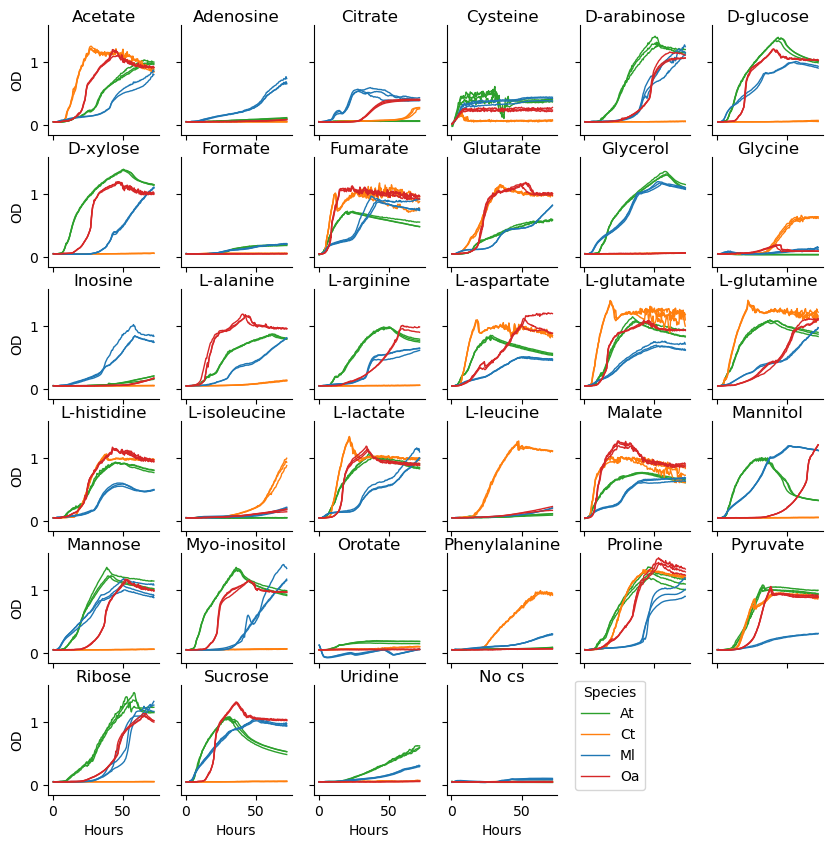

In [141]:
fig, axes = plt.subplots(n_rows, n_cols, figsize = (10, 10), sharex = True, sharey = True)
kmax = 33
for i in range(n_rows):
    for j in range(n_cols):
        k = (i*n_cols)+j
        if k <= kmax:
            cs = cs_list[k]
            data = df.loc[(df['Carbon source']==cs)&(df.Hours<max_time),:]
            axes[i,j].set_title(cs, pad = -50)
            axes[i,j].spines[['right', 'top']].set_visible(False)
            if k==kmax:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j],#OD600
                    units="Well", estimator=None, lw=1, hue_order=['At', 'Ct', 'Ml', 'Oa'], palette=palette)# ci='sd')
                sns.move_legend(axes[i,j], "upper left", bbox_to_anchor=(1.1, 1.1))
            else:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], legend=None, #OD600
                    units="Well", estimator=None, lw=1, hue_order=['At', 'Ct', 'Ml', 'Oa'], palette=palette)# ci='sd')
            # axes[i,j].set_ylim(1e-4, 2)
            # axes[i,j].set_yscale('log')

        else:
            axes[i,j].axis('off')

plt.savefig('all_od_curves_all_lines.pdf')
plt.show()

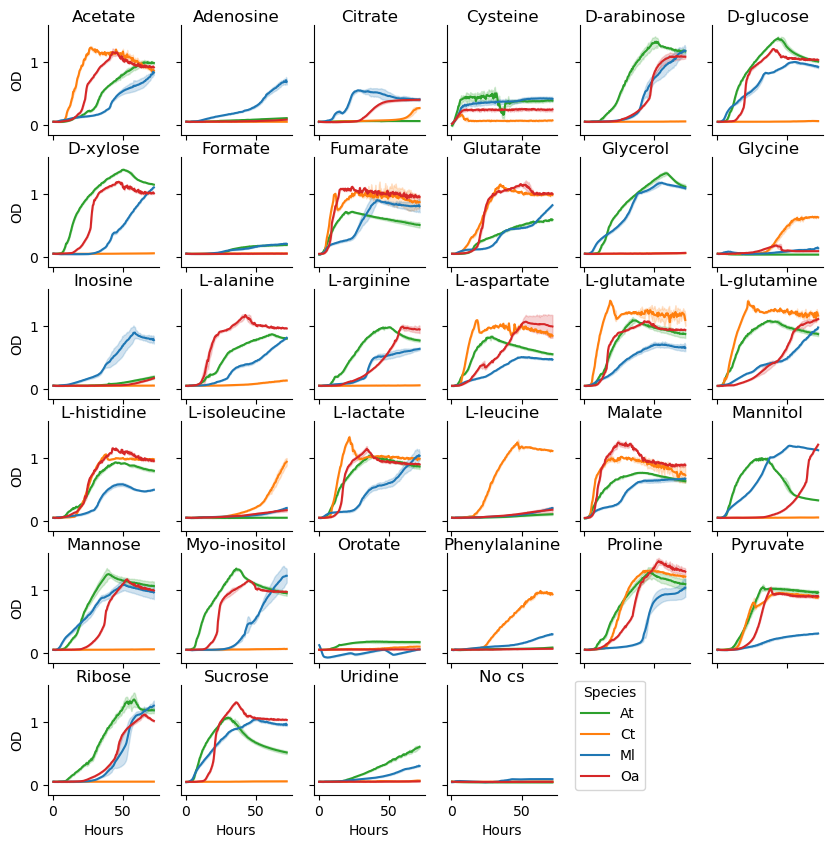

In [108]:
fig, axes = plt.subplots(n_rows, n_cols, figsize = (10, 10), sharex = True, sharey = True)
kmax = 33
for i in range(n_rows):
    for j in range(n_cols):
        k = (i*n_cols)+j
        if k <= kmax:
            cs = cs_list[k]
            data = df.loc[(df['Carbon source']==cs)&(df.Hours<max_time),:]
            axes[i,j].set_title(cs, pad = -50)
            axes[i,j].spines[['right', 'top']].set_visible(False)
            if k==kmax:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j],
                    errorbar='sd', hue_order=['At', 'Ct', 'Ml', 'Oa'], palette=palette)
                sns.move_legend(axes[i,j], "upper left", bbox_to_anchor=(1.1, 1.1))
            else:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], legend=None, 
                    errorbar='sd', hue_order=['At', 'Ct', 'Ml', 'Oa'], palette=palette)
            # axes[i,j].set_ylim(1e-4, 2)
            # axes[i,j].set_yscale('log')

        else:
            axes[i,j].axis('off')
plt.savefig('all_od_curves_sd.pdf')
plt.show()

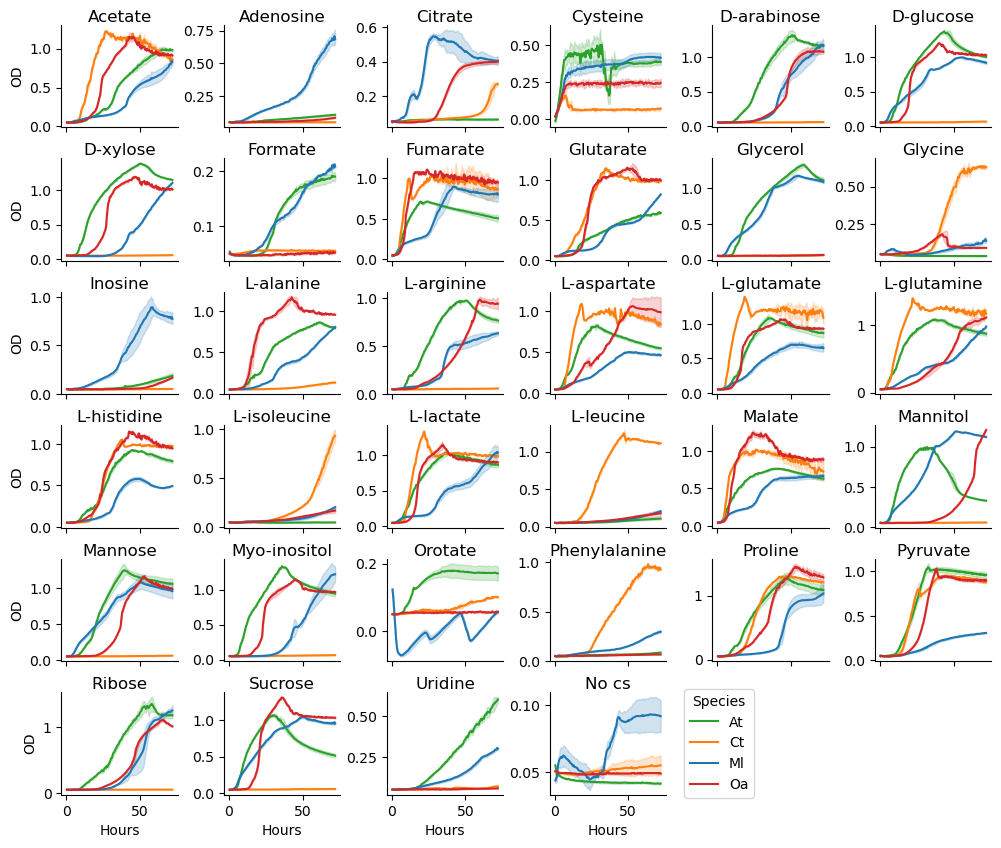

In [109]:
fig, axes = plt.subplots(n_rows, n_cols, figsize = (12, 10), sharex = True, sharey = False)
kmax = 33
for i in range(n_rows):
    for j in range(n_cols):
        k = (i*n_cols)+j
        if k <= kmax:
            cs = cs_list[k]
            data = df.loc[(df['Carbon source']==cs)&(df.Hours<max_time),:]
            axes[i,j].set_title(cs, pad = -50)
            axes[i,j].spines[['right', 'top']].set_visible(False)
            if k==kmax:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], errorbar='sd', hue_order=['At', 'Ct', 'Ml', 'Oa'], palette=palette)
                sns.move_legend(axes[i,j], "upper left", bbox_to_anchor=(1.1, 1.1))
            else:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], legend=None, errorbar='sd', hue_order=['At', 'Ct', 'Ml', 'Oa'], palette=palette)
            if not k%6==0:
                axes[i,j].set_ylabel("")
            # axes[i,j].set_ylim(1e-4, 2)
            # axes[i,j].set_yscale('log')

        else:
            axes[i,j].axis('off')
# plt.tight_layout()
plt.subplots_adjust(wspace=0.4, hspace = 0.3)
plt.savefig('all_od_curves_separate_scale_sd.pdf')
plt.show()

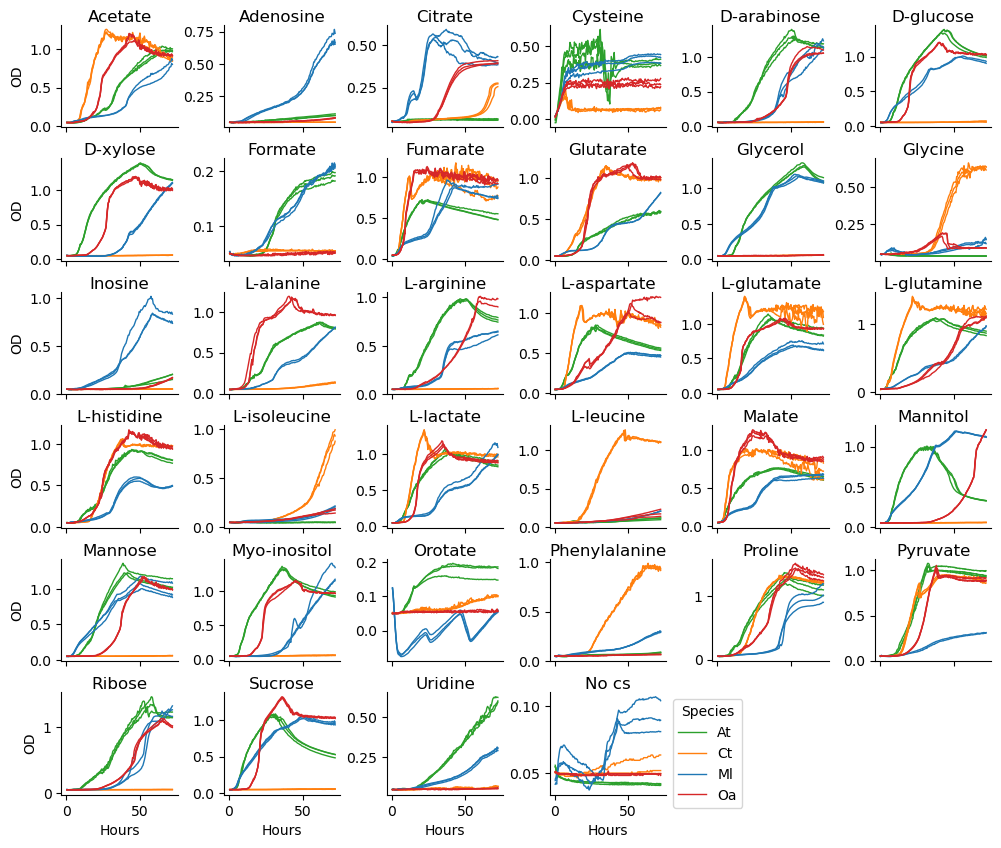

In [110]:
fig, axes = plt.subplots(n_rows, n_cols, figsize = (12, 10), sharex = True, sharey = False)
kmax = 33
for i in range(n_rows):
    for j in range(n_cols):
        k = (i*n_cols)+j
        if k <= kmax:
            cs = cs_list[k]
            data = df.loc[(df['Carbon source']==cs)&(df.Hours<max_time),:]
            axes[i,j].set_title(cs, pad = -50)
            axes[i,j].spines[['right', 'top']].set_visible(False)
            if k==kmax:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], 
                             units="Well", estimator=None, lw=1, hue_order=['At', 'Ct', 'Ml', 'Oa'], palette=palette)# ci='sd')
                sns.move_legend(axes[i,j], "upper left", bbox_to_anchor=(1, 1))
            else:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], legend=None, 
                             units="Well", estimator=None, lw=1, hue_order=['At', 'Ct', 'Ml', 'Oa'], palette=palette)# ci='sd')
            if not k%6==0:
                axes[i,j].set_ylabel("")
            # axes[i,j].set_ylim(1e-4, 2)
            # axes[i,j].set_yscale('log')

        else:
            axes[i,j].axis('off')
# plt.tight_layout()
plt.subplots_adjust(wspace=0.4, hspace = 0.3)
plt.savefig('all_od_curves_separate_scale_all_lines.pdf')


# Convert to binary results
- The general rule -> p-val < 1e-3, yield >0.05
- Exception: Oa on L-leucine - Shape of growth curve indicates that this is actually growth

In [171]:
from scipy.stats import ttest_ind 

In [172]:
bool_dict = {}
p_val_dict = {}
yield_dict = {}
p_val_threshold = 1e-3
max_time_t0 = 2
for species in ['At','Ct', 'Ml', 'Oa']:
    dfs = df.loc[df.Species == species,:]
    # df['Carbon source'] = df.Well.map(well_to_cs)
    # df.loc[:, 'OD600'] = pd.to_numeric(df.loc[:, 'OD600'])
    t0 = dfs.Hours.unique()[:4] 
    no_cs = dfs.loc[dfs['Carbon source']=='No cs',:]
    no_cs_yield = no_cs.groupby('Well').max()['OD'] - no_cs.loc[no_cs['Hours']<max_time_t0,:].groupby('Well').mean(numeric_only=True)['OD']
    p_val_arr = np.zeros(len(cs_list))
    bool_arr = np.zeros(len(cs_list))
    yield_arr = np.zeros(len(cs_list))
    for i, cs in enumerate(cs_list):
        cs_df = dfs.loc[dfs['Carbon source']==cs,:]
        cs_yield = cs_df.groupby('Well').max()['OD'] - cs_df.loc[cs_df['Hours']<max_time_t0,:].groupby('Well').mean(numeric_only=True)['OD']
        t_val, p2 = ttest_ind(cs_yield, no_cs_yield)
        p_val_arr[i] = p2/2
        bool_arr[i] = ((p2/2) < p_val_threshold) and (cs_yield.mean() > 0.05)
        yield_arr[i] = cs_yield.mean()
    yield_dict[species] = yield_arr
    bool_dict[species] = bool_arr
    p_val_dict[species] = p_val_arr
    print(species, no_cs_yield.mean())


At 0.004041666666666666
Ct 0.005166666666666664
Ml 0.04999999999999999
Oa 0.0009999999999999916


In [173]:
bool_df = pd.DataFrame(bool_dict, index = cs_list).astype(bool)
p_val_df = pd.DataFrame(p_val_dict, index = cs_list)
yield_df = pd.DataFrame(yield_dict, index = cs_list)

In [175]:
bool_df.at['L-leucine', 'Oa'] = True

In [176]:
bool_df.to_csv('growth_no_growth.csv')
p_val_df.to_csv('growth_no_growth_p_value.csv')
yield_df.to_csv('yield.csv')


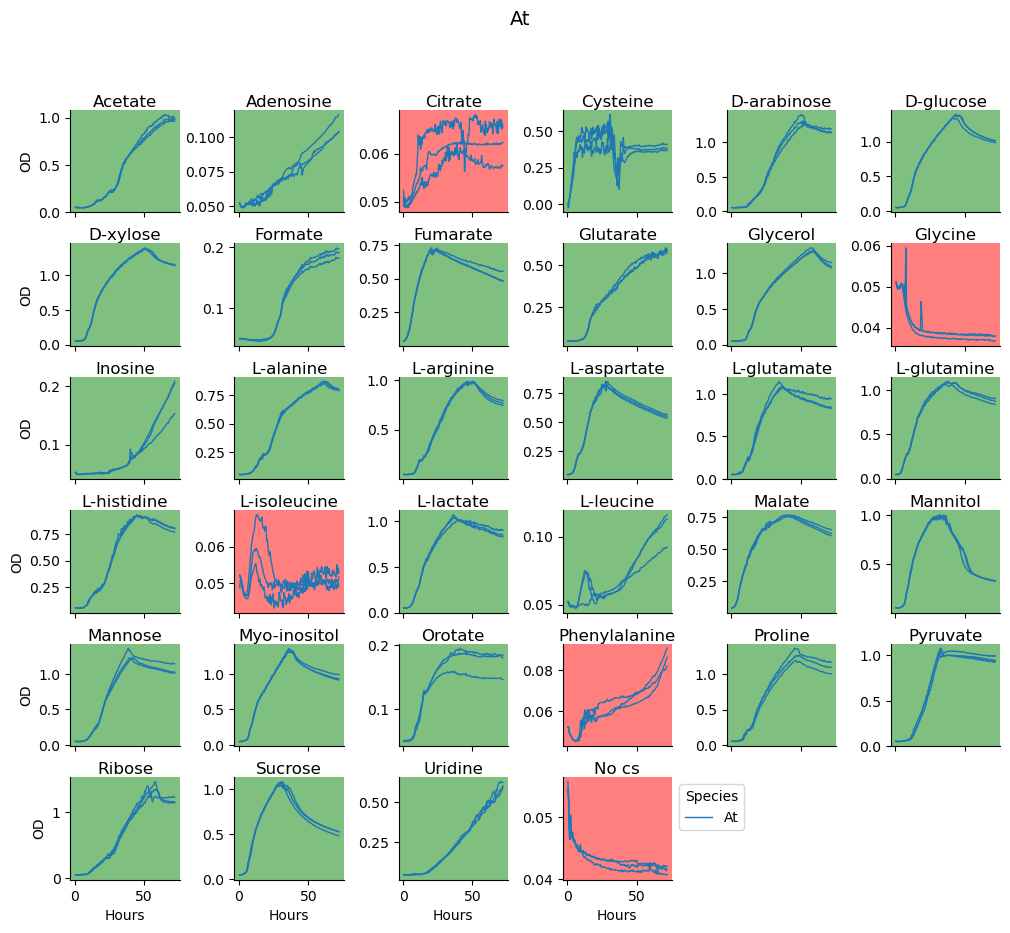

In [184]:
fig, axes = plt.subplots(n_rows, n_cols, figsize = (12, 10), sharex = True, sharey = False)
kmax = 33
species = 'At'
fig.suptitle(species, size = 14)
for i in range(n_rows):
    for j in range(n_cols):
        k = (i*n_cols)+j
        if k <= kmax:
            cs = cs_list[k]
            data = df.loc[(df['Carbon source']==cs)&(df.Hours<max_time),:]
            data = data.loc[data.Species == species,:]
            axes[i,j].set_title(cs, pad = -50)
            axes[i,j].spines[['right', 'top']].set_visible(False)
            if k==kmax:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], 
                             units="Well", estimator=None, lw=1)# ci='sd')
                sns.move_legend(axes[i,j], "upper left", bbox_to_anchor=(1, 1))
            else:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], legend=None, 
                             units="Well", estimator=None, lw=1)# ci='sd')
            if bool_df.at[cs, species]:
                axes[i,j].patch.set_facecolor('g')
            else:
                axes[i,j].patch.set_facecolor('r')
            if not k%6==0:
                axes[i,j].set_ylabel("")
            axes[i,j].patch.set_alpha(0.5)
            # axes[i,j].set_ylim(1e-4, 2)
            # axes[i,j].set_yscale('log')

        else:
            axes[i,j].axis('off')
plt.subplots_adjust(wspace = 0.5, hspace = 0.3)
plt.savefig('{0}_od_curves_separate_scale_all_lines_classified.pdf'.format(species))

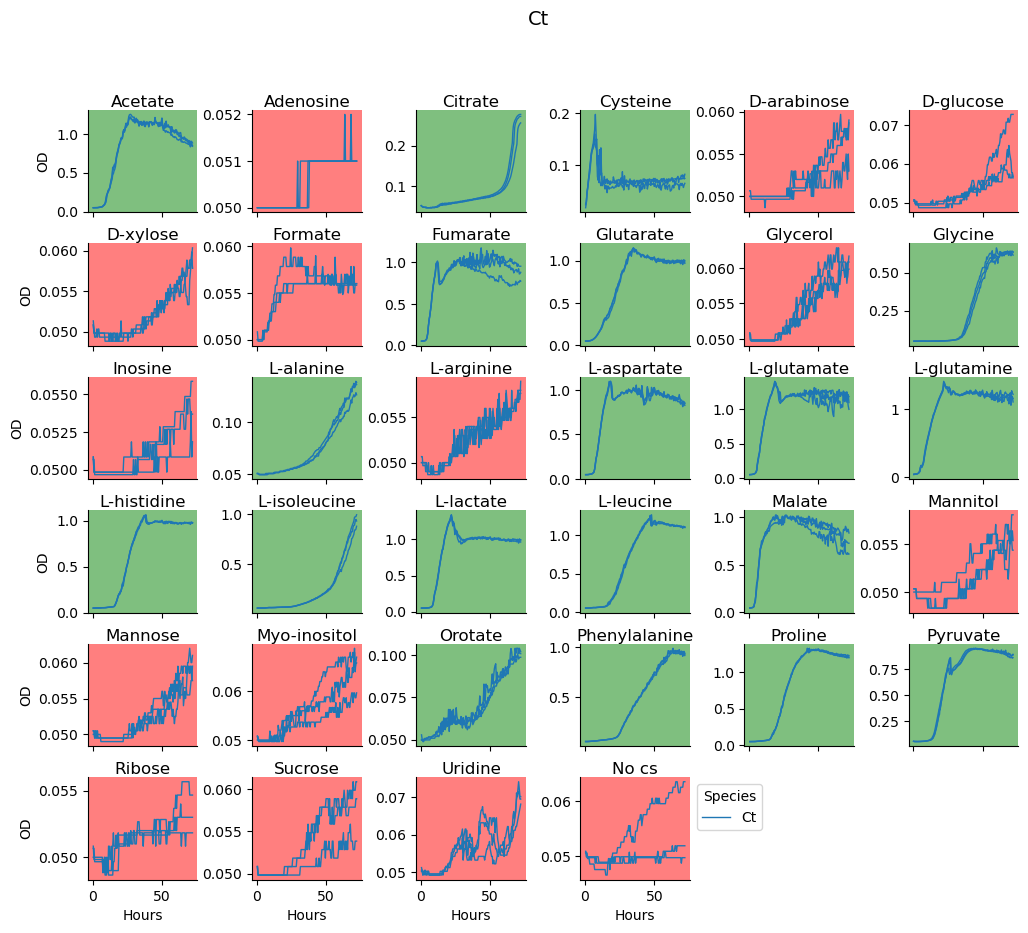

In [185]:
fig, axes = plt.subplots(n_rows, n_cols, figsize = (12, 10), sharex = True, sharey = False)
kmax = 33
species = 'Ct'
fig.suptitle(species, size = 14)
for i in range(n_rows):
    for j in range(n_cols):
        k = (i*n_cols)+j
        if k <= kmax:
            cs = cs_list[k]
            data = df.loc[(df['Carbon source']==cs)&(df.Hours<max_time),:]
            data = data.loc[data.Species == species,:]
            axes[i,j].set_title(cs, pad = -50)
            axes[i,j].spines[['right', 'top']].set_visible(False)
            if k==kmax:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], 
                             units="Well", estimator=None, lw=1)# ci='sd')
                sns.move_legend(axes[i,j], "upper left", bbox_to_anchor=(1, 1))
            else:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], legend=None, 
                             units="Well", estimator=None, lw=1)# ci='sd')
            if bool_df.at[cs, species]:
                axes[i,j].patch.set_facecolor('g')
            else:
                axes[i,j].patch.set_facecolor('r')
            if not k%6==0:
                axes[i,j].set_ylabel("")
            axes[i,j].patch.set_alpha(0.5)
            # axes[i,j].set_ylim(1e-4, 2)
            # axes[i,j].set_yscale('log')

        else:
            axes[i,j].axis('off')
plt.subplots_adjust(wspace = 0.5, hspace = 0.3)
plt.savefig('{0}_od_curves_separate_scale_all_lines_classified.pdf'.format(species))

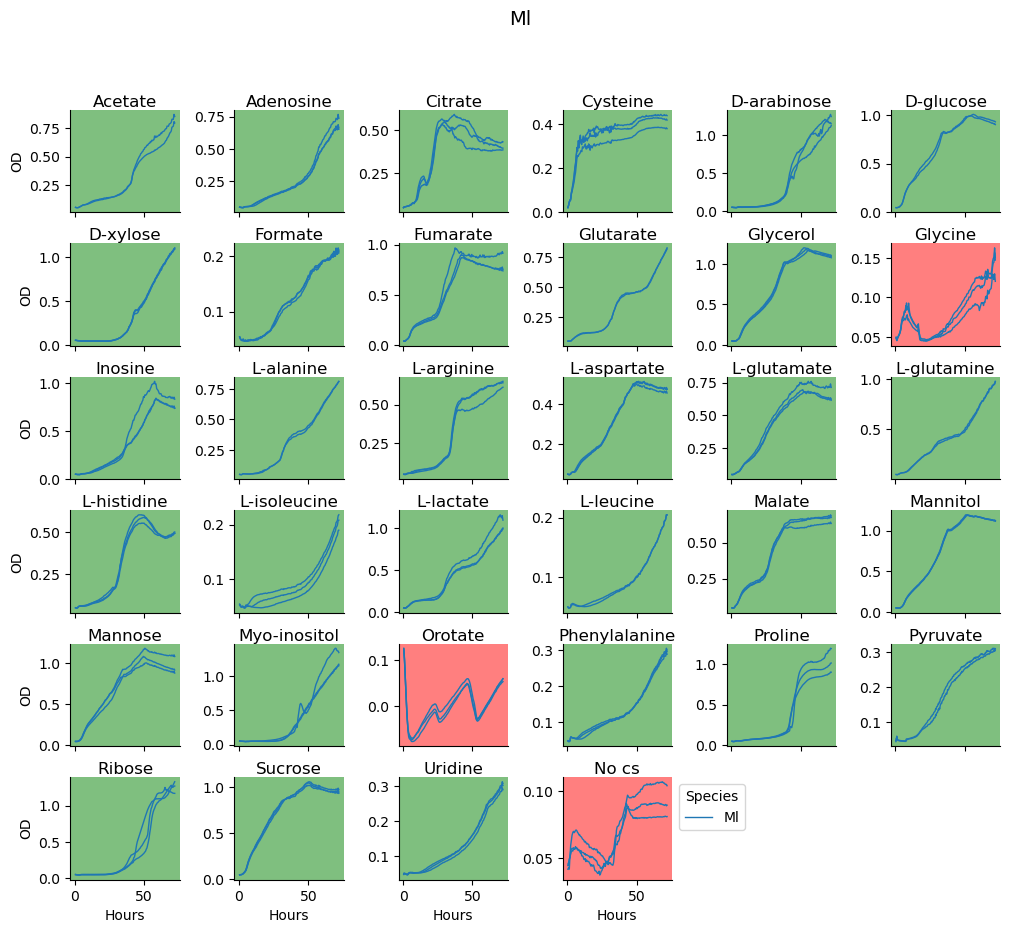

In [186]:
fig, axes = plt.subplots(n_rows, n_cols, figsize = (12, 10), sharex = True, sharey = False)
kmax = 33
species = 'Ml'
fig.suptitle(species, size = 14)
for i in range(n_rows):
    for j in range(n_cols):
        k = (i*n_cols)+j
        if k <= kmax:
            cs = cs_list[k]
            data = df.loc[(df['Carbon source']==cs)&(df.Hours<max_time),:]
            data = data.loc[data.Species == species,:]
            axes[i,j].set_title(cs, pad = -50)
            axes[i,j].spines[['right', 'top']].set_visible(False)
            if k==kmax:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], 
                             units="Well", estimator=None, lw=1)# ci='sd')
                sns.move_legend(axes[i,j], "upper left", bbox_to_anchor=(1, 1))
            else:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], legend=None, 
                             units="Well", estimator=None, lw=1)# ci='sd')
            if bool_df.at[cs, species]:
                axes[i,j].patch.set_facecolor('g')
            else:
                axes[i,j].patch.set_facecolor('r')
            if not k%6==0:
                axes[i,j].set_ylabel("")
            axes[i,j].patch.set_alpha(0.5)
            # axes[i,j].set_ylim(1e-4, 2)
            # axes[i,j].set_yscale('log')

        else:
            axes[i,j].axis('off')
plt.subplots_adjust(wspace = 0.5, hspace = 0.3)
plt.savefig('{0}_od_curves_separate_scale_all_lines_classified.pdf'.format(species))

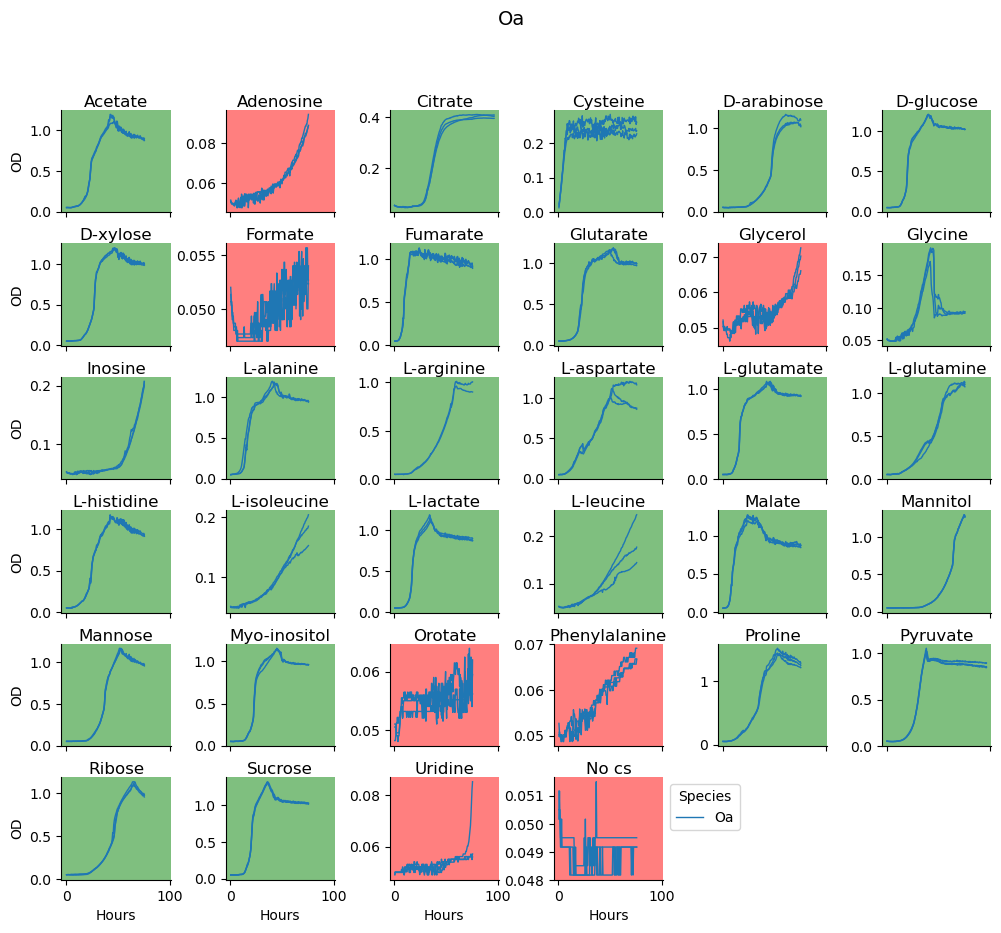

In [187]:
fig, axes = plt.subplots(n_rows, n_cols, figsize = (12, 10), sharex = True, sharey = False)
kmax = 33
species = 'Oa'
fig.suptitle(species, size = 14)
for i in range(n_rows):
    for j in range(n_cols):
        k = (i*n_cols)+j
        if k <= kmax:
            cs = cs_list[k]
            data = df.loc[df['Carbon source']==cs,:]
            data = data.loc[data.Species == species,:]
            axes[i,j].set_title(cs, pad = -50)
            axes[i,j].spines[['right', 'top']].set_visible(False)
            if k==kmax:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], 
                             units="Well", estimator=None, lw=1)# ci='sd')
                sns.move_legend(axes[i,j], "upper left", bbox_to_anchor=(1, 1))
            else:
                sns.lineplot(data = data,  x = 'Hours', y = 'OD', hue = 'Species', ax = axes[i,j], legend=None, 
                             units="Well", estimator=None, lw=1)# ci='sd')
            if bool_df.at[cs, species]:
                axes[i,j].patch.set_facecolor('g')
            else:
                axes[i,j].patch.set_facecolor('r')
            if not k%6==0:
                axes[i,j].set_ylabel("")
            axes[i,j].patch.set_alpha(0.5)
            # axes[i,j].set_ylim(1e-4, 2)
            # axes[i,j].set_yscale('log')

        else:
            axes[i,j].axis('off')
plt.subplots_adjust(wspace = 0.5, hspace = 0.3)
plt.savefig('{0}_od_curves_separate_scale_all_lines_classified.pdf'.format(species))

# Plot heatmap